In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv('data/raw/kc_house_data.csv')
df.head()
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

## Verification of missing values

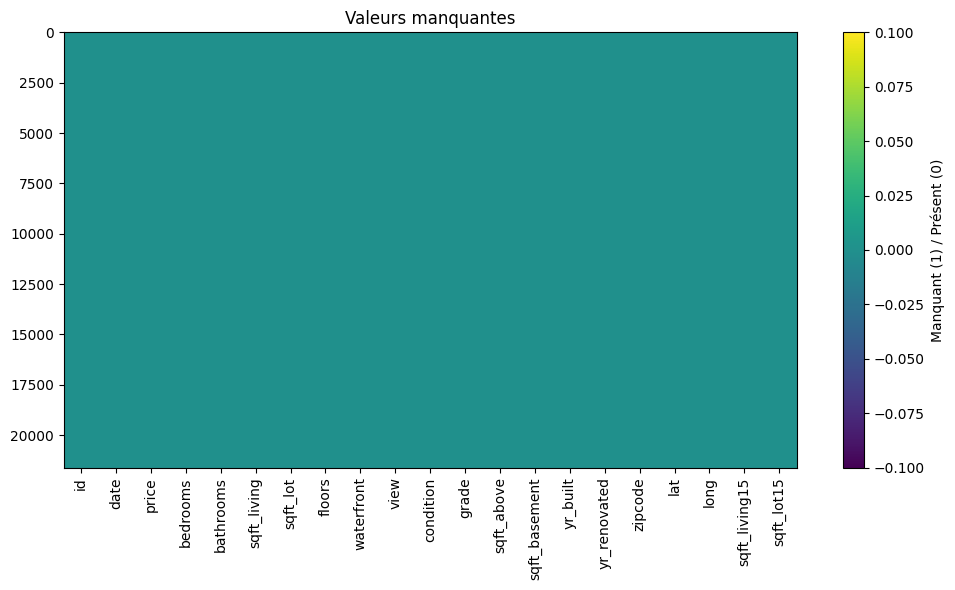

In [23]:
# valeur manquante dans le dataset
plt.figure(figsize=(10,6))
plt.imshow(df.isnull(), cmap="viridis", aspect="auto", interpolation="none")
plt.colorbar(label="Manquant (1) / Présent (0)")
plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.title("Valeurs manquantes")
plt.tight_layout()
plt.show()


## Verification of duplicates values 

In [22]:
# Vérification des doublons dans le dataset
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


## Colums traitements

In [24]:
#normalisation de la colonne date
df['date'] = pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S')
print(df['date'].head())

0   2014-10-13
1   2014-12-09
2   2015-02-25
3   2014-12-09
4   2015-02-18
Name: date, dtype: datetime64[ns]


## Traitement and display 

#### price distribution 

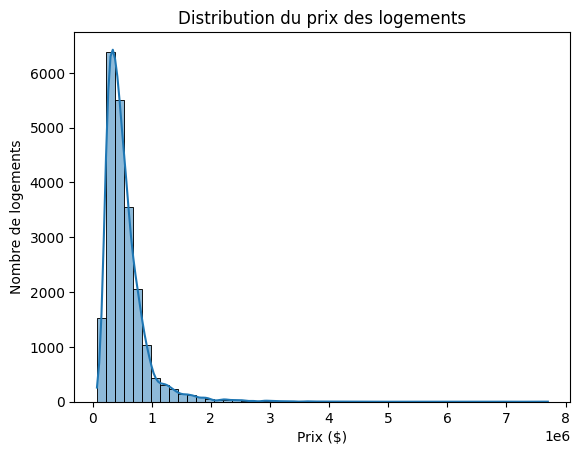

In [28]:
sns.histplot(data=df, x="price", kde=True, bins=50)
plt.title("Distribution du prix des logements")
plt.xlabel("Prix ($)")
plt.ylabel("Nombre de logements")
plt.show()

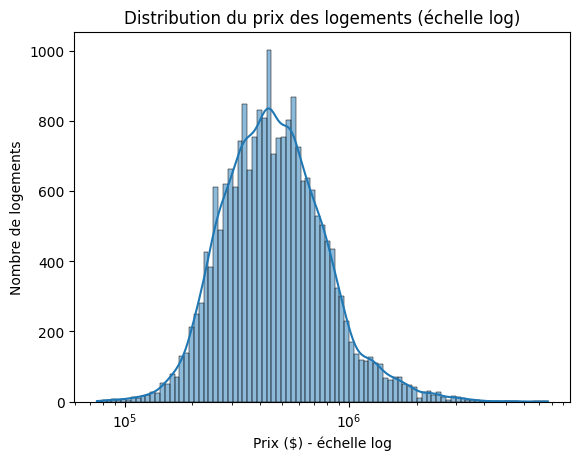

In [35]:
sns.histplot(data=df, x="price", kde=True, log_scale=True)
plt.title("Distribution du prix des logements (échelle log)")
plt.xlabel("Prix ($) - échelle log")
plt.ylabel("Nombre de logements")
plt.show()

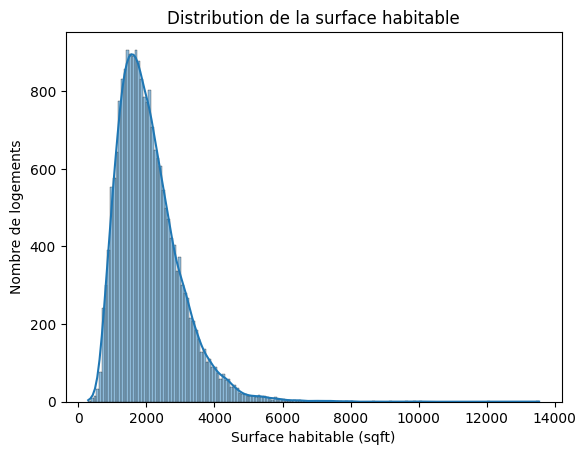

In [36]:
sns.histplot(data=df, x="sqft_living", kde=True)
plt.title("Distribution de la surface habitable")
plt.xlabel("Surface habitable (sqft)")
plt.ylabel("Nombre de logements")
plt.show()

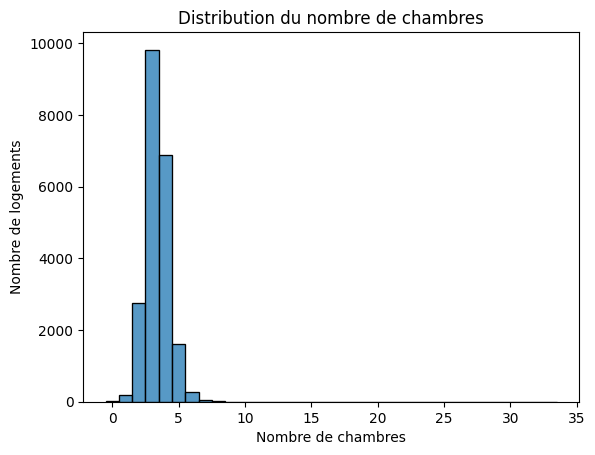

In [37]:
sns.histplot(data=df, x="bedrooms", discrete=True)
plt.title("Distribution du nombre de chambres")
plt.xlabel("Nombre de chambres")
plt.ylabel("Nombre de logements")
plt.show()

### Boxoplot 

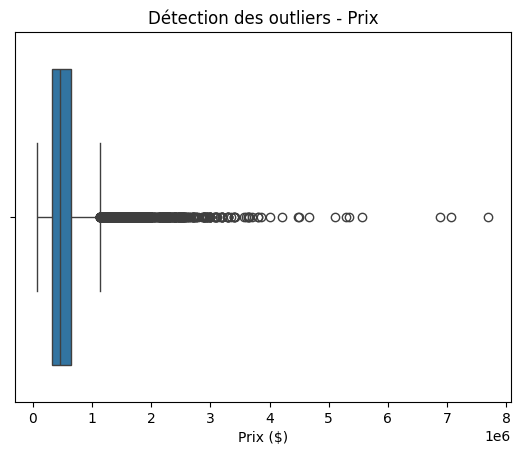

In [39]:
sns.boxplot(data=df, x="price")
plt.title("Détection des outliers - Prix")
plt.xlabel("Prix ($)")
plt.show()

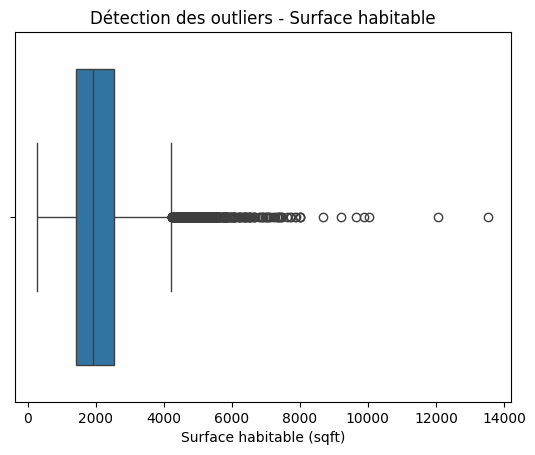

In [40]:
sns.boxplot(data=df, x="sqft_living")
plt.title("Détection des outliers - Surface habitable")
plt.xlabel("Surface habitable (sqft)")
plt.show()


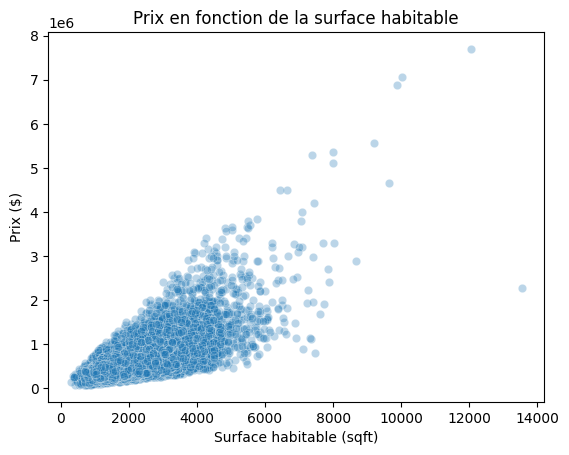

In [41]:
sns.scatterplot(data=df, x="sqft_living", y="price", alpha=0.3)
plt.title("Prix en fonction de la surface habitable")
plt.xlabel("Surface habitable (sqft)")
plt.ylabel("Prix ($)")
plt.show()

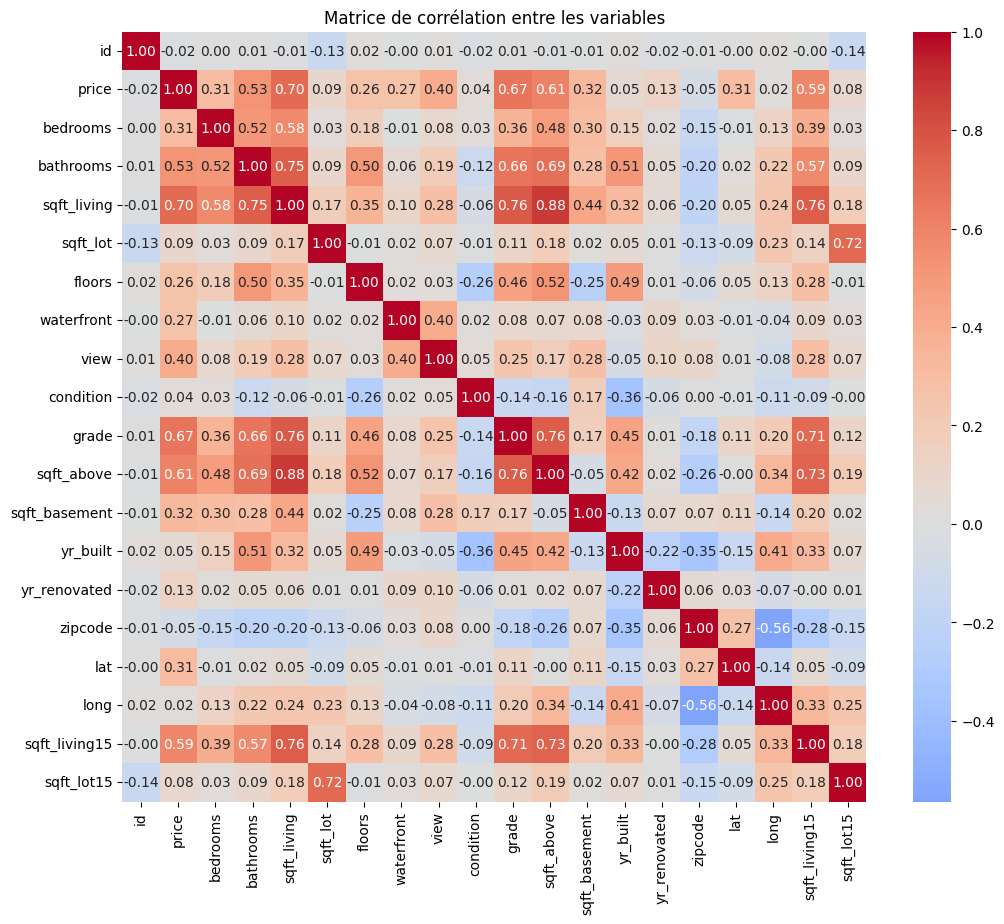

In [43]:
plt.figure(figsize=(12,10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matrice de corrélation entre les variables")
plt.show()